In [1]:
%pip install tqdm pyarrow
%pip install seaborn
%pip install scipy


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Prep for parallelization and fast running

In [2]:
%%writefile scenario_worker.py
import copy
import numpy as np
from scenario_class import Scenario

# We must put the base params here so the worker file knows about them
base_scenario_params = {
    "end_year": 2100,
    "carbon_budget": 1150 * 0.95 - 2 * 35,
    "gdp_assumption": "constant_ratio",
    "pop_growth_assumption": "semi_log_model",
    "tech_evolution_assumption": "plausible",
    "tech_hysteresis_assumption": "optimistic_degrowth",
    "steady_state_high_income_assumption": "off",
    "k": 0.05,
    "t0": 2060,
    "population_hysteresis_assumption": "on", # Updated based on recent script changes
    "run_until_2100": "on",
    "cdr_level_2100": 5,
    # "elasticity_assumption" and "elasticity_value" are set dynamically below
}

def run_single_scenario_with_deciles(param_tuple):
    """
    Runs a single iteration of the scenario and returns the extracted trajectory rows.
    """
    # 1. Unpack 6 variables to include the elasticity assumption type
    inc, cdr, degrowth, fir, elast_assump, elast_val = param_tuple
    
    params = copy.deepcopy(base_scenario_params)
    params["income_goal"] = inc
    params["cdr_assumption"] = cdr
    params["tech_hysteresis_assumption"] = degrowth 
    params["final_improvement_rate"] = fir
    
    # 2. Map to the new elasticity parameter names
    params["elasticity_assumption"] = elast_assump
    params["elasticity_value"] = elast_val
    
    scenario = Scenario(params)
    scenario.compute_country_scenario_params() # 3. CRITICAL: Required by new scenario architecture
    scenario.run()
    
    scenario_rows = []
    
    for country_name, country in scenario.countries.items():
        for year in country.gdp_trajectory.keys():
            if year > params["end_year"]:
                continue
            
            pop = country.population_trajectory.get(year, np.nan)
            gdp = country.gdp_trajectory.get(year, np.nan)
            gdppc = country.gdppc_trajectory.get(year, np.nan)
            tot_emissions = country.emissions_trajectory.get(year, np.nan)
            gini = country.gini_coefficient_trajectory.get(year, np.nan)
            
            for d in range(1, 11):
                d_key = f'decile{d}'
                
                decile_income = country.decile_trajectories.get(d_key, {}).get(year, np.nan)
                decile_emissions_pc = country.decile_emissions_trajectories_pc.get(d_key, {}).get(year, np.nan)
                decile_absolute_emissions = country.decile_emissions_trajectories.get(d_key, {}).get(year, np.nan)
                
                row = {
                    "Income_Goal": inc,
                    "CDR_Assumption": cdr,
                    "Degrowth_Assumption": degrowth, 
                    "Final_Improvement_Rate": fir,
                    "Elasticity_Assumption": elast_assump,
                    "Elasticity": elast_val, # Kept as 'Elasticity' to avoid breaking your plot code
                    "Country": country_name,
                    "Country_Code": getattr(country, 'code', 'UNKNOWN'),
                    "Year": year,
                    "Decile": d,
                    "Decile_Income": decile_income,
                    "Decile_Emissions_pc": decile_emissions_pc,
                    "Decile_Emissions_Absolute": decile_absolute_emissions,
                    "Macro_Population": pop,
                    "Macro_GDP": gdp,
                    "Macro_GDP_pc": gdppc,
                    "Macro_Total_Emissions": tot_emissions,
                    "Gini": gini
                }
                scenario_rows.append(row)
                
    return scenario_rows

Overwriting scenario_worker.py


In [3]:
import os
import sys
# 1. Safely change the current working directory to the main project root.
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    os.chdir('..')

# 2. Add the 'model_code' folder to sys.path so Python can find your classes
module_path = os.path.abspath('model_code')
if module_path not in sys.path:
    sys.path.append(module_path)

In [4]:
import itertools
import numpy as np
import pandas as pd
import os # Added for path handling
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm

# Import the worker function from the physical file we just created
from scenario_worker import run_single_scenario_with_deciles

if __name__ == '__main__':
    # Grids
    income_goals = list(range(5000, 35000, 5000)) 
    cdr_assumptions = ["on"]
    degrowth_assumptions = ["optimistic_degrowth", "pessimistic_degrowth"]
    final_improvement_rates = [-0.05] 
    
    # ---> ADDED ELASTICITY ASSUMPTIONS GRID <---
    elasticity_assumptions = ["absolute_income_elasticity"]
    elasticities = np.round(np.arange(0.7, 1.1, 0.1), 2) 

    permutations = list(itertools.product(
        income_goals, cdr_assumptions, degrowth_assumptions, final_improvement_rates, elasticity_assumptions, elasticities
    ))

    total_runs = len(permutations)
    print(f"Total scenario combinations to run: {total_runs}")
    print("Warning: Decile extraction will generate roughly 10x the rows. Expect a large dataset.")

    master_results = []

    # Execute in Parallel
    with ProcessPoolExecutor() as executor:
        futures = {executor.submit(run_single_scenario_with_deciles, p): p for p in permutations}
        
        for future in tqdm(as_completed(futures), total=total_runs, desc="Running Scenarios"):
            try:
                result_rows = future.result()
                master_results.extend(result_rows)
            except Exception as e:
                failed_params = futures[future]
                print(f"Scenario failed for parameters {failed_params}: {e}")

    print(f"Total rows generated: {len(master_results):,}")

    # Convert to DataFrame and save
    print("Converting to DataFrame...")
    df_master = pd.DataFrame(master_results)

    # ---> UPDATED PATHS TO SAVE IN ../data/ <---
    os.makedirs("../data", exist_ok=True) # Ensure the directory exists just in case
    parquet_filename = "../data/scenario_results_with_deciles.parquet"
    print(f"Saving to {parquet_filename} (Parquet format)...")
    
    try:
        df_master.to_parquet(parquet_filename, index=False)
        print("Done! The file is ready for analysis.")
    except ImportError:
        print("You don't have pyarrow installed. Falling back to CSV...")
        csv_filename = "../data/scenario_results_with_deciles.csv"
        df_master.to_csv(csv_filename, index=False)
        print(f"Done! Saved to {csv_filename}.")

Total scenario combinations to run: 60


Running Scenarios:   0%|          | 0/60 [00:00<?, ?it/s]

Total rows generated: 7,110,000
Converting to DataFrame...
Saving to ../data/scenario_results_with_deciles.parquet (Parquet format)...
Done! The file is ready for analysis.


## Supp fig6 Elasticity influence on emissions Germany 

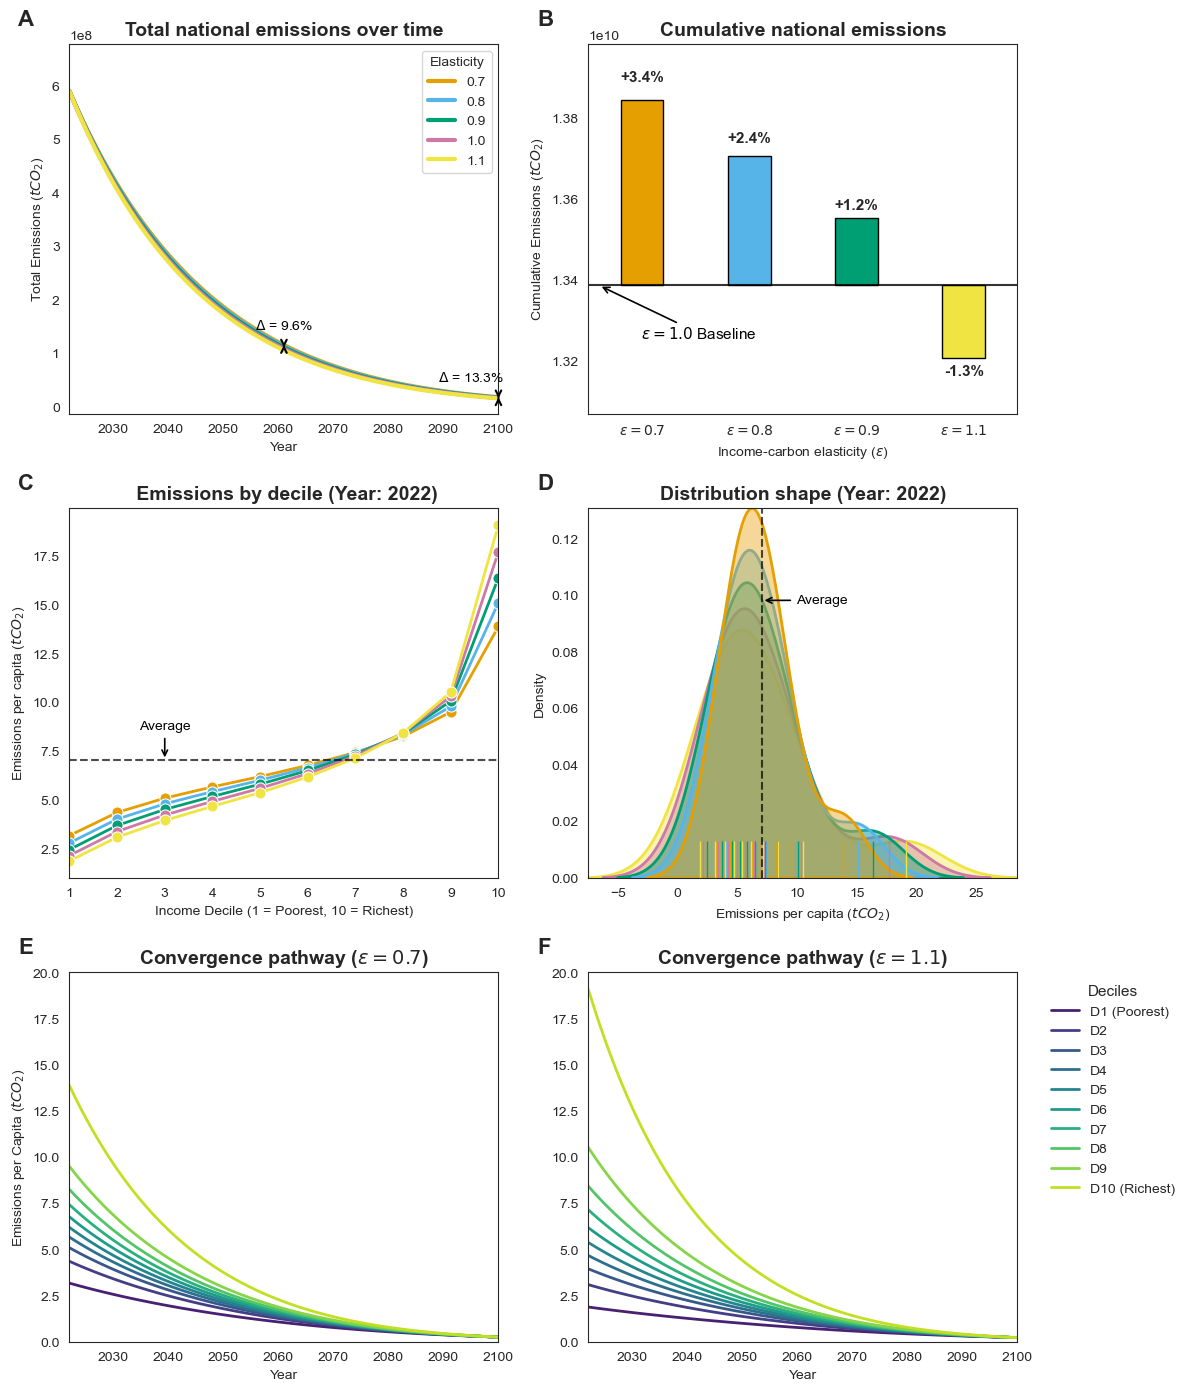

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data & Set Target Scenario
# ==========================================
# ---> UPDATED PATHS TO LOAD FROM ../data/ <---
try:
    df = pd.read_parquet("../data/scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("../data/scenario_results_with_deciles.csv")

# Scenario Parameters
target_income = 20000
target_fir = -0.05
target_cdr = "on"  # <--- FIXED: Changed from "off" to "on" to match your generated data
target_country = "Germany"
degrowth_assumptions = ["pessimistic_degrowth"]  # List of degrowth assumptions to consider

# Isolate the specific scenario
df_scenario = df[
    (df["Income_Goal"] == target_income) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr) &
    (df["Degrowth_Assumption"].isin(degrowth_assumptions))
].copy()

# Ensure we have a clean string for deciles to sort legends easily
df_scenario["Decile_Label"] = df_scenario["Decile"].apply(
    lambda d: f"D{d} (Poorest)" if d == 1 else (f"D{d} (Richest)" if d == 10 else f"D{d}")
)


# ==============================================================================
# FIGURE 1: The New 6-Panel Mosaic Plot
# ==============================================================================
# Enforce a clean white background
sns.set_style("white")

df_country = df_scenario[df_scenario["Country"] == target_country].copy()
df_macro_country = df_country[['Year', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# <--- FIXED: Dynamically find the first year to ensure df_snapshot is never empty
snapshot_year = df_country["Year"].min() if not df_country.empty else 2023 

# Define the new mosaic layout (3 rows, 2 columns): 
# Row 1: A (Left), B (Right)
# Row 2: C (Left), D (Right)
# Row 3: E (Left), F (Right)
layout = """
AB
CD
EF
"""
# Adjusted figsize to accommodate the new 6-panel grid gracefully
fig, axes = plt.subplot_mosaic(layout, figsize=(12, 14))
fig.patch.set_facecolor('white')

# Colorblind-friendly Okabe-Ito palette
cb_colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#F0E442", "#0072B2", "#D55E00", "#000000"]

# Ensure color consistency by manually mapping sorted elasticities
unique_elasticities = sorted(df_macro_country['Elasticity'].unique())
color_dict = {e: cb_colors[i % len(cb_colors)] for i, e in enumerate(unique_elasticities)}

# --- PANEL A: Macro Total Emissions Trajectories ---
sns.lineplot(
    data=df_macro_country, x="Year", y="Macro_Total_Emissions", 
    hue="Elasticity", palette=list(color_dict.values()), linewidth=3, ax=axes['A']
)
axes['A'].set_title("Total national emissions over time", fontsize=14, fontweight='bold')
axes['A'].set_ylabel("Total Emissions ($tCO_2$)")
axes['A'].grid(False) # Gridlines removed
axes['A'].margins(x=0) # 0 margins
axes['A'].text(-0.12, 1.05, "A", transform=axes['A'].transAxes, fontsize=16, fontweight='bold')

# Add per year diff annotation as PERCENTAGE (midway and last year to illustrate magnitude)
years = sorted(df_macro_country['Year'].unique())
if len(years) > 1:
    last_year = years[-1]
    mid_year = years[len(years) // 2]
    
    # Store overall max to add safe padding above the lines
    overall_max = df_macro_country['Macro_Total_Emissions'].max()
    y_padding = overall_max * 0.04 # Standardized padding
    
    # === ANNOTATION 1: Mid Year (Explicitly separated for easy positioning) ===
    y1_data = df_macro_country[df_macro_country['Year'] == mid_year]
    y1_max = y1_data['Macro_Total_Emissions'].max()
    y1_min = y1_data['Macro_Total_Emissions'].min()
    
    pct1_diff = ((y1_max - y1_min) / y1_min) * 100
    # Changed from .2g to .1f to display exact dynamic decimals
    pct1_str = f"{pct1_diff:.1f}"
        
    axes['A'].annotate('', xy=(mid_year, y1_max), xytext=(mid_year, y1_min),
                       arrowprops=dict(arrowstyle='<->', lw=1.5, color='black'))
    
    # You can change 'mid_year' and 'y1_max + y_padding' here to manually shift this specific text
    axes['A'].text(mid_year, y1_max + y_padding, f"$\Delta$ = {pct1_str}%", 
                   va='bottom', ha='center', fontsize=10, color='black')


    # === ANNOTATION 2: Last Year (Explicitly separated for easy positioning) ===
    y2_data = df_macro_country[df_macro_country['Year'] == last_year]
    y2_max = y2_data['Macro_Total_Emissions'].max()
    y2_min = y2_data['Macro_Total_Emissions'].min()
    
    pct2_diff = ((y2_max - y2_min) / y2_min) * 100
    # Changed from .2g to .1f to display exact dynamic decimals
    pct2_str = f"{pct2_diff:.1f}"
        
    axes['A'].annotate('', xy=(last_year, y2_max), xytext=(last_year, y2_min),
                       arrowprops=dict(arrowstyle='<->', lw=1.5, color='black'))
    
    # You can change 'last_year' and 'y2_max + y_padding' here to manually shift this specific text
    axes['A'].text(last_year - 5, y2_max + y_padding, f"$\Delta$ = {pct2_str}%", 
                   va='bottom', ha='center', fontsize=10, color='black')

    # Increase the top y-limit slightly so the new top-placed text isn't cut off
    axes['A'].set_ylim(top=overall_max * 1.15)


# --- PANEL B: Cumulative Emissions Waterfall Chart ---
cum_emissions = df_macro_country.groupby('Elasticity')['Macro_Total_Emissions'].sum().reset_index()

# Attempt to find the elasticity = 1.0 baseline
base_row = cum_emissions[cum_emissions['Elasticity'] == 1.0]
if not base_row.empty:
    base_val = base_row['Macro_Total_Emissions'].values[0]
    # Filter out the baseline so we don't plot its bar
    df_plot = cum_emissions[cum_emissions['Elasticity'] != 1.0].copy()
else:
    # Fallback if exactly 1.0 is missing
    base_val = cum_emissions['Macro_Total_Emissions'].median() if not cum_emissions.empty else 0
    df_plot = cum_emissions[cum_emissions['Macro_Total_Emissions'] != base_val].copy()

axes['B'].set_title("Cumulative national emissions", fontsize=14, fontweight='bold')
axes['B'].set_ylabel("Cumulative Emissions ($tCO_2$)")
axes['B'].set_xlabel("Income-carbon elasticity ($\epsilon$)")
axes['B'].grid(False) 
axes['B'].text(-0.12, 1.05, "B", transform=axes['B'].transAxes, fontsize=16, fontweight='bold')

# Draw the baseline for Elasticity 1.0
if base_val > 0:
    axes['B'].axhline(base_val, color='black', linewidth=1.5, linestyle='-', alpha=0.8)

    # Place the baseline text with an offset and arrow pointing to the line to avoid overlapping the bars
    axes['B'].annotate('$\epsilon = 1.0$ Baseline', xy=(-0.4, base_val), 
                       xytext=(30, -40), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                       va='bottom', ha='left', fontsize=11, color='black',
                       bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

# Plot the floating bars (waterfall style)
x_positions = np.arange(len(df_plot))
for idx, (index, row) in enumerate(df_plot.iterrows()):
    e = row['Elasticity']
    val = row['Macro_Total_Emissions']
    delta = val - base_val
    
    # Plot the floating block starting from base_val
    axes['B'].bar(
        x=idx, 
        height=delta, 
        bottom=base_val, 
        color=color_dict.get(e, 'grey'), 
        edgecolor='black', 
        width=0.4
    )
    
    # Annotate percentage delta
    if base_val > 0:
        pct = (delta / base_val) * 100
        sign = "+" if pct > 0 else ""
        # Changed from .2g to .1f to display exact dynamic decimals
        pct_str = f"{sign}{pct:.1f}%"
            
        va = 'bottom' if delta > 0 else 'top'
        offset = abs(delta) * 0.08 if delta != 0 else base_val * 0.01
        y_pos = val + offset if delta > 0 else val - offset
        
        axes['B'].text(
            x=idx, 
            y=y_pos, 
            s=pct_str, 
            ha='center', 
            va=va, 
            fontsize=11, 
            fontweight='bold'
        )

axes['B'].set_xticks(x_positions)
axes['B'].set_xticklabels([f"$\epsilon = {e}$" for e in df_plot['Elasticity']])
axes['B'].set_xlim(-0.5, len(df_plot) - 0.5)

# Adjust y-limits so text is clearly visible above/below the floating blocks
y_min, y_max = axes['B'].get_ylim()
range_y = y_max - y_min
if range_y == 0:
    range_y = base_val * 0.1
axes['B'].set_ylim(y_min - range_y * 0.15, y_max + range_y * 0.15)


# --- PANEL C: Initial Decile Line Plot ---
df_snapshot = df_country[df_country["Year"] == snapshot_year]

# <--- FIXED: Safe iloc extraction checking if empty to prevent IndexError
snapshot_means = df_snapshot.groupby('Elasticity')['Decile_Emissions_pc'].mean()
if not snapshot_means.empty:
    assert np.allclose(snapshot_means, snapshot_means.iloc[0]), "Average emissions are not constant across elasticities!"
    avg_emission = snapshot_means.iloc[0]
else:
    avg_emission = 0

sns.lineplot(
    data=df_snapshot, x="Decile", y="Decile_Emissions_pc", hue="Elasticity", 
    palette=list(color_dict.values()), marker="o", markersize=8, linewidth=2, ax=axes['C'], legend=False
)
axes['C'].set_title(f" Emissions by decile (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['C'].set_xlabel("Income Decile (1 = Poorest, 10 = Richest)")
axes['C'].set_ylabel("Emissions per capita ($tCO_2$)")
axes['C'].set_xticks(range(1, 11))
axes['C'].grid(False) # Gridlines removed
axes['C'].margins(x=0) # 0 margins
axes['C'].text(-0.12, 1.05, "C", transform=axes['C'].transAxes, fontsize=16, fontweight='bold')

# Add average line and offset annotation with an arrow
if avg_emission > 0:
    axes['C'].axhline(avg_emission, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    axes['C'].annotate('Average', xy=(3, avg_emission), xytext=(0, 20), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                       va='bottom', ha='center', fontsize=10, color='black')


# --- PANEL D: KDE Distribution Comparison ---
sns.kdeplot(
    data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
    palette=list(color_dict.values()), fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes['D'], legend=False
)
if not df_snapshot.empty:
    sns.rugplot(
        data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
        palette=list(color_dict.values()), height=0.1, ax=axes['D'], legend=False
    )
axes['D'].set_title(f"Distribution shape (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['D'].set_xlabel("Emissions per capita ($tCO_2$)")
axes['D'].set_ylabel("Density")
axes['D'].grid(False) # Gridlines removed
axes['D'].margins(x=0, y=0) # 0 margins
axes['D'].text(-0.12, 1.05, "D", transform=axes['D'].transAxes, fontsize=16, fontweight='bold')

# Add average line and offset annotation with an arrow
if avg_emission > 0:
    axes['D'].axvline(avg_emission, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    axes['D'].annotate('Average', xy=(avg_emission, 0.75), xycoords=('data', 'axes fraction'),
                       xytext=(25, 0), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                       va='center', ha='left', fontsize=10, color='black')


# --- PANEL E: Decile Emissions Over Time (Elasticity = 0.7) ---
df_elast_low = df_country[df_country["Elasticity"] == 0.7].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_low, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['E'], legend=False
)
axes['E'].set_title("Convergence pathway ($\epsilon = 0.7$)", fontsize=14, fontweight='bold')
axes['E'].set_xlabel("Year")
axes['E'].set_ylabel("Emissions per Capita ($tCO_2$)")
axes['E'].grid(False) # Gridlines removed
axes['E'].margins(x=0) # 0 margins
axes['E'].text(-0.12, 1.05, "E", transform=axes['E'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL F: Decile Emissions Over Time (Elasticity = 1.1) ---
df_elast_high = df_country[df_country["Elasticity"] == 1.1].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_high, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['F']
)
axes['F'].set_title("Convergence pathway ($\epsilon = 1.1$)", fontsize=14, fontweight='bold')
axes['F'].set_xlabel("Year")
axes['F'].set_ylabel("") # Shared visually with E
axes['F'].grid(False) # Gridlines removed
axes['F'].margins(x=0) # 0 margins
axes['F'].text(-0.12, 1.05, "F", transform=axes['F'].transAxes, fontsize=16, fontweight='bold')


# --- Synchronize Y-Axis for Panels E and F ---
max_y_pathway = 0
if not df_elast_low.empty and not df_elast_high.empty:
    max_y_pathway = max(df_elast_low["Decile_Emissions_pc"].max(), df_elast_high["Decile_Emissions_pc"].max())
    axes['E'].set_ylim(0, max_y_pathway * 1.05)
    axes['F'].set_ylim(0, max_y_pathway * 1.05)

# Clean up legend for Panel F
axes['F'].legend(title="Deciles", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=10, title_fontsize=11)

# Add explicit padding to prevent any overlapping
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=3.0)
plt.subplots_adjust(top=0.94)

import os

# --- DIRECTORY LOGIC ---
# Determine if we are currently inside 'jupyter_scripts'
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    # We are in jupyter_scripts, step up one level to the root
    output_dir = os.path.join('..', 'figures_supplementary')
else:
    # We are already in the root directory (Convergence)
    output_dir = 'figures_supplementary'

os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'supp_fig6.png')

plt.tight_layout() # Optional, but good practice to ensure nothing is cut off
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

## Supp fig7 Elasticity influence on emissions Nigeria

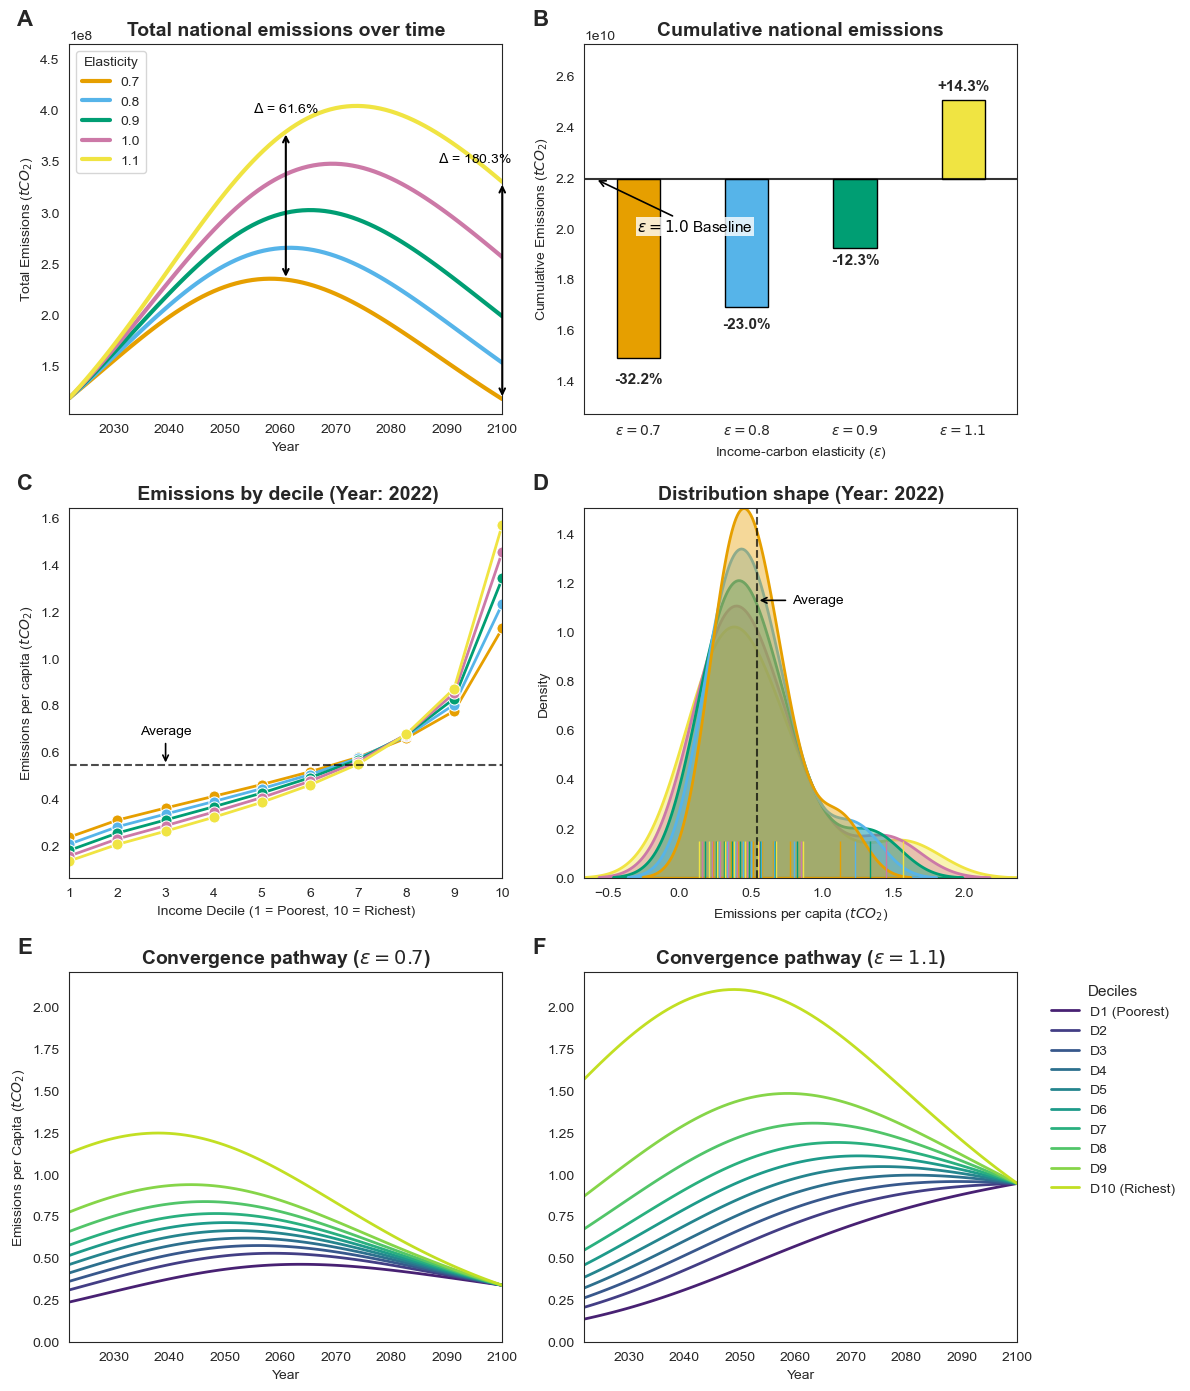

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data & Set Target Scenario
# ==========================================
# ---> UPDATED PATHS TO LOAD FROM ../data/ <---
try:
    df = pd.read_parquet("../data/scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("../data/scenario_results_with_deciles.csv")

# Scenario Parameters
target_income = 20000
target_fir = -0.05
target_cdr = "on"  # <--- FIXED: Changed from "off" to "on" to match your generated dataset
target_country = "Nigeria"
degrowth_assumptions = ["optimistic_degrowth"]  # List of degrowth assumptions to consider

# Isolate the specific scenario
df_scenario = df[
    (df["Income_Goal"] == target_income) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr) &
    (df["Degrowth_Assumption"].isin(degrowth_assumptions))
].copy()

# Ensure we have a clean string for deciles to sort legends easily
df_scenario["Decile_Label"] = df_scenario["Decile"].apply(
    lambda d: f"D{d} (Poorest)" if d == 1 else (f"D{d} (Richest)" if d == 10 else f"D{d}")
)


# ==============================================================================
# FIGURE 1: The New 6-Panel Mosaic Plot
# ==============================================================================
# Enforce a clean white background
sns.set_style("white")

df_country = df_scenario[df_scenario["Country"] == target_country].copy()
df_macro_country = df_country[['Year', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# <--- FIXED: Dynamically find the first year so it doesn't crash if the DataFrame is empty
snapshot_year = df_country["Year"].min() if not df_country.empty else 2023 

# Define the new mosaic layout (3 rows, 2 columns): 
# Row 1: A (Left), B (Right)
# Row 2: C (Left), D (Right)
# Row 3: E (Left), F (Right)
layout = """
AB
CD
EF
"""
# Adjusted figsize to accommodate the new 6-panel grid gracefully
fig, axes = plt.subplot_mosaic(layout, figsize=(12, 14))
fig.patch.set_facecolor('white')

# Colorblind-friendly Okabe-Ito palette
cb_colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#F0E442", "#0072B2", "#D55E00", "#000000"]

# Ensure color consistency by manually mapping sorted elasticities
unique_elasticities = sorted(df_macro_country['Elasticity'].unique())
color_dict = {e: cb_colors[i % len(cb_colors)] for i, e in enumerate(unique_elasticities)}

# --- PANEL A: Macro Total Emissions Trajectories ---
sns.lineplot(
    data=df_macro_country, x="Year", y="Macro_Total_Emissions", 
    hue="Elasticity", palette=list(color_dict.values()), linewidth=3, ax=axes['A']
)
axes['A'].set_title("Total national emissions over time", fontsize=14, fontweight='bold')
axes['A'].set_ylabel("Total Emissions ($tCO_2$)")
axes['A'].grid(False) # Gridlines removed
axes['A'].margins(x=0) # 0 margins
axes['A'].text(-0.12, 1.05, "A", transform=axes['A'].transAxes, fontsize=16, fontweight='bold')

# Add per year diff annotation as PERCENTAGE (midway and last year to illustrate magnitude)
years = sorted(df_macro_country['Year'].unique())
if len(years) > 1:
    last_year = years[-1]
    mid_year = years[len(years) // 2]
    
    # Store overall max to add safe padding above the lines
    overall_max = df_macro_country['Macro_Total_Emissions'].max()
    y_padding = overall_max * 0.04 # Standardized padding
    
    # === ANNOTATION 1: Mid Year (Explicitly separated for easy positioning) ===
    y1_data = df_macro_country[df_macro_country['Year'] == mid_year]
    y1_max = y1_data['Macro_Total_Emissions'].max()
    y1_min = y1_data['Macro_Total_Emissions'].min()
    
    pct1_diff = ((y1_max - y1_min) / y1_min) * 100
    # Changed from .2g to .1f to display exact dynamic decimals
    pct1_str = f"{pct1_diff:.1f}"
        
    axes['A'].annotate('', xy=(mid_year, y1_max), xytext=(mid_year, y1_min),
                       arrowprops=dict(arrowstyle='<->', lw=1.5, color='black'))
    
    # You can change 'mid_year' and 'y1_max + y_padding' here to manually shift this specific text
    axes['A'].text(mid_year, y1_max + y_padding, f"$\Delta$ = {pct1_str}%", 
                   va='bottom', ha='center', fontsize=10, color='black')


    # === ANNOTATION 2: Last Year (Explicitly separated for easy positioning) ===
    y2_data = df_macro_country[df_macro_country['Year'] == last_year]
    y2_max = y2_data['Macro_Total_Emissions'].max()
    y2_min = y2_data['Macro_Total_Emissions'].min()
    
    pct2_diff = ((y2_max - y2_min) / y2_min) * 100
    # Changed from .2g to .1f to display exact dynamic decimals
    pct2_str = f"{pct2_diff:.1f}"
        
    axes['A'].annotate('', xy=(last_year, y2_max), xytext=(last_year, y2_min),
                       arrowprops=dict(arrowstyle='<->', lw=1.5, color='black'))
    
    # You can change 'last_year' and 'y2_max + y_padding' here to manually shift this specific text
    axes['A'].text(last_year - 5, y2_max + y_padding, f"$\Delta$ = {pct2_str}%", 
                   va='bottom', ha='center', fontsize=10, color='black')

    # Increase the top y-limit slightly so the new top-placed text isn't cut off
    axes['A'].set_ylim(top=overall_max * 1.15)


# --- PANEL B: Cumulative Emissions Waterfall Chart ---
cum_emissions = df_macro_country.groupby('Elasticity')['Macro_Total_Emissions'].sum().reset_index()

# Attempt to find the elasticity = 1.0 baseline
base_row = cum_emissions[cum_emissions['Elasticity'] == 1.0]
if not base_row.empty:
    base_val = base_row['Macro_Total_Emissions'].values[0]
    # Filter out the baseline so we don't plot its bar
    df_plot = cum_emissions[cum_emissions['Elasticity'] != 1.0].copy()
else:
    # Fallback if exactly 1.0 is missing
    base_val = cum_emissions['Macro_Total_Emissions'].median() if not cum_emissions.empty else 0
    df_plot = cum_emissions[cum_emissions['Macro_Total_Emissions'] != base_val].copy()

axes['B'].set_title("Cumulative national emissions", fontsize=14, fontweight='bold')
axes['B'].set_ylabel("Cumulative Emissions ($tCO_2$)")
axes['B'].set_xlabel("Income-carbon elasticity ($\epsilon$)")
axes['B'].grid(False) 
axes['B'].text(-0.12, 1.05, "B", transform=axes['B'].transAxes, fontsize=16, fontweight='bold')

# Draw the baseline for Elasticity 1.0
if base_val > 0:
    axes['B'].axhline(base_val, color='black', linewidth=1.5, linestyle='-', alpha=0.8)

    # Place the baseline text with an offset and arrow pointing to the line to avoid overlapping the bars
    axes['B'].annotate('$\epsilon = 1.0$ Baseline', xy=(-0.4, base_val), 
                       xytext=(30, -40), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                       va='bottom', ha='left', fontsize=11, color='black',
                       bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

# Plot the floating bars (waterfall style)
x_positions = np.arange(len(df_plot))
for idx, (index, row) in enumerate(df_plot.iterrows()):
    e = row['Elasticity']
    val = row['Macro_Total_Emissions']
    delta = val - base_val
    
    # Plot the floating block starting from base_val
    axes['B'].bar(
        x=idx, 
        height=delta, 
        bottom=base_val, 
        color=color_dict.get(e, 'grey'), 
        edgecolor='black', 
        width=0.4
    )
    
    # Annotate percentage delta
    if base_val > 0:
        pct = (delta / base_val) * 100
        sign = "+" if pct > 0 else ""
        # Changed from .2g to .1f to display exact dynamic decimals
        pct_str = f"{sign}{pct:.1f}%"
            
        va = 'bottom' if delta > 0 else 'top'
        offset = abs(delta) * 0.08 if delta != 0 else base_val * 0.01
        y_pos = val + offset if delta > 0 else val - offset
        
        axes['B'].text(
            x=idx, 
            y=y_pos, 
            s=pct_str, 
            ha='center', 
            va=va, 
            fontsize=11, 
            fontweight='bold'
        )

axes['B'].set_xticks(x_positions)
axes['B'].set_xticklabels([f"$\epsilon = {e}$" for e in df_plot['Elasticity']])
axes['B'].set_xlim(-0.5, len(df_plot) - 0.5)

# Adjust y-limits so text is clearly visible above/below the floating blocks
y_min, y_max = axes['B'].get_ylim()
range_y = y_max - y_min
if range_y == 0:
    range_y = base_val * 0.1
axes['B'].set_ylim(y_min - range_y * 0.15, y_max + range_y * 0.15)


# --- PANEL C: Initial Decile Line Plot ---
df_snapshot = df_country[df_country["Year"] == snapshot_year]

# <--- FIXED: Safe iloc extraction checking if empty to prevent IndexError
snapshot_means = df_snapshot.groupby('Elasticity')['Decile_Emissions_pc'].mean()
if not snapshot_means.empty:
    assert np.allclose(snapshot_means, snapshot_means.iloc[0]), "Average emissions are not constant across elasticities!"
    avg_emission = snapshot_means.iloc[0]
else:
    avg_emission = 0

sns.lineplot(
    data=df_snapshot, x="Decile", y="Decile_Emissions_pc", hue="Elasticity", 
    palette=list(color_dict.values()), marker="o", markersize=8, linewidth=2, ax=axes['C'], legend=False
)
axes['C'].set_title(f" Emissions by decile (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['C'].set_xlabel("Income Decile (1 = Poorest, 10 = Richest)")
axes['C'].set_ylabel("Emissions per capita ($tCO_2$)")
axes['C'].set_xticks(range(1, 11))
axes['C'].grid(False) # Gridlines removed
axes['C'].margins(x=0) # 0 margins
axes['C'].text(-0.12, 1.05, "C", transform=axes['C'].transAxes, fontsize=16, fontweight='bold')

# Add average line and offset annotation with an arrow
if avg_emission > 0:
    axes['C'].axhline(avg_emission, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    axes['C'].annotate('Average', xy=(3, avg_emission), xytext=(0, 20), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                       va='bottom', ha='center', fontsize=10, color='black')


# --- PANEL D: KDE Distribution Comparison ---
sns.kdeplot(
    data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
    palette=list(color_dict.values()), fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes['D'], legend=False
)
if not df_snapshot.empty:
    sns.rugplot(
        data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
        palette=list(color_dict.values()), height=0.1, ax=axes['D'], legend=False
    )
axes['D'].set_title(f"Distribution shape (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['D'].set_xlabel("Emissions per capita ($tCO_2$)")
axes['D'].set_ylabel("Density")
axes['D'].grid(False) # Gridlines removed
axes['D'].margins(x=0, y=0) # 0 margins
axes['D'].text(-0.12, 1.05, "D", transform=axes['D'].transAxes, fontsize=16, fontweight='bold')

# Add average line and offset annotation with an arrow
if avg_emission > 0:
    axes['D'].axvline(avg_emission, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    axes['D'].annotate('Average', xy=(avg_emission, 0.75), xycoords=('data', 'axes fraction'),
                       xytext=(25, 0), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                       va='center', ha='left', fontsize=10, color='black')


# --- PANEL E: Decile Emissions Over Time (Elasticity = 0.7) ---
df_elast_low = df_country[df_country["Elasticity"] == 0.7].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_low, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['E'], legend=False
)
axes['E'].set_title("Convergence pathway ($\epsilon = 0.7$)", fontsize=14, fontweight='bold')
axes['E'].set_xlabel("Year")
axes['E'].set_ylabel("Emissions per Capita ($tCO_2$)")
axes['E'].grid(False) # Gridlines removed
axes['E'].margins(x=0) # 0 margins
axes['E'].text(-0.12, 1.05, "E", transform=axes['E'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL F: Decile Emissions Over Time (Elasticity = 1.1) ---
df_elast_high = df_country[df_country["Elasticity"] == 1.1].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_high, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['F']
)
axes['F'].set_title("Convergence pathway ($\epsilon = 1.1$)", fontsize=14, fontweight='bold')
axes['F'].set_xlabel("Year")
axes['F'].set_ylabel("") # Shared visually with E
axes['F'].grid(False) # Gridlines removed
axes['F'].margins(x=0) # 0 margins
axes['F'].text(-0.12, 1.05, "F", transform=axes['F'].transAxes, fontsize=16, fontweight='bold')


# --- Synchronize Y-Axis for Panels E and F ---
# <--- FIXED: Safely calculate the max y-limit to avoid errors on empty data
max_y_pathway = 0
if not df_elast_low.empty and not df_elast_high.empty:
    max_y_pathway = max(df_elast_low["Decile_Emissions_pc"].max(), df_elast_high["Decile_Emissions_pc"].max())
    axes['E'].set_ylim(0, max_y_pathway * 1.05)
    axes['F'].set_ylim(0, max_y_pathway * 1.05)

# Clean up legend for Panel F
axes['F'].legend(title="Deciles", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=10, title_fontsize=11)

# Add explicit padding to prevent any overlapping
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=3.0)
plt.subplots_adjust(top=0.94)

# --- DIRECTORY LOGIC (Navigate up one level) ---
import os

# --- DIRECTORY LOGIC ---
# Determine if we are currently inside 'jupyter_scripts'
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    # We are in jupyter_scripts, step up one level to the root
    output_dir = os.path.join('..', 'figures_supplementary')
else:
    # We are already in the root directory (Convergence)
    output_dir = 'figures_supplementary'

os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'supp_fig7.png')

plt.tight_layout() # Optional, but good practice to ensure nothing is cut off
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

## suppfig8 Elasticity influence on emissions China

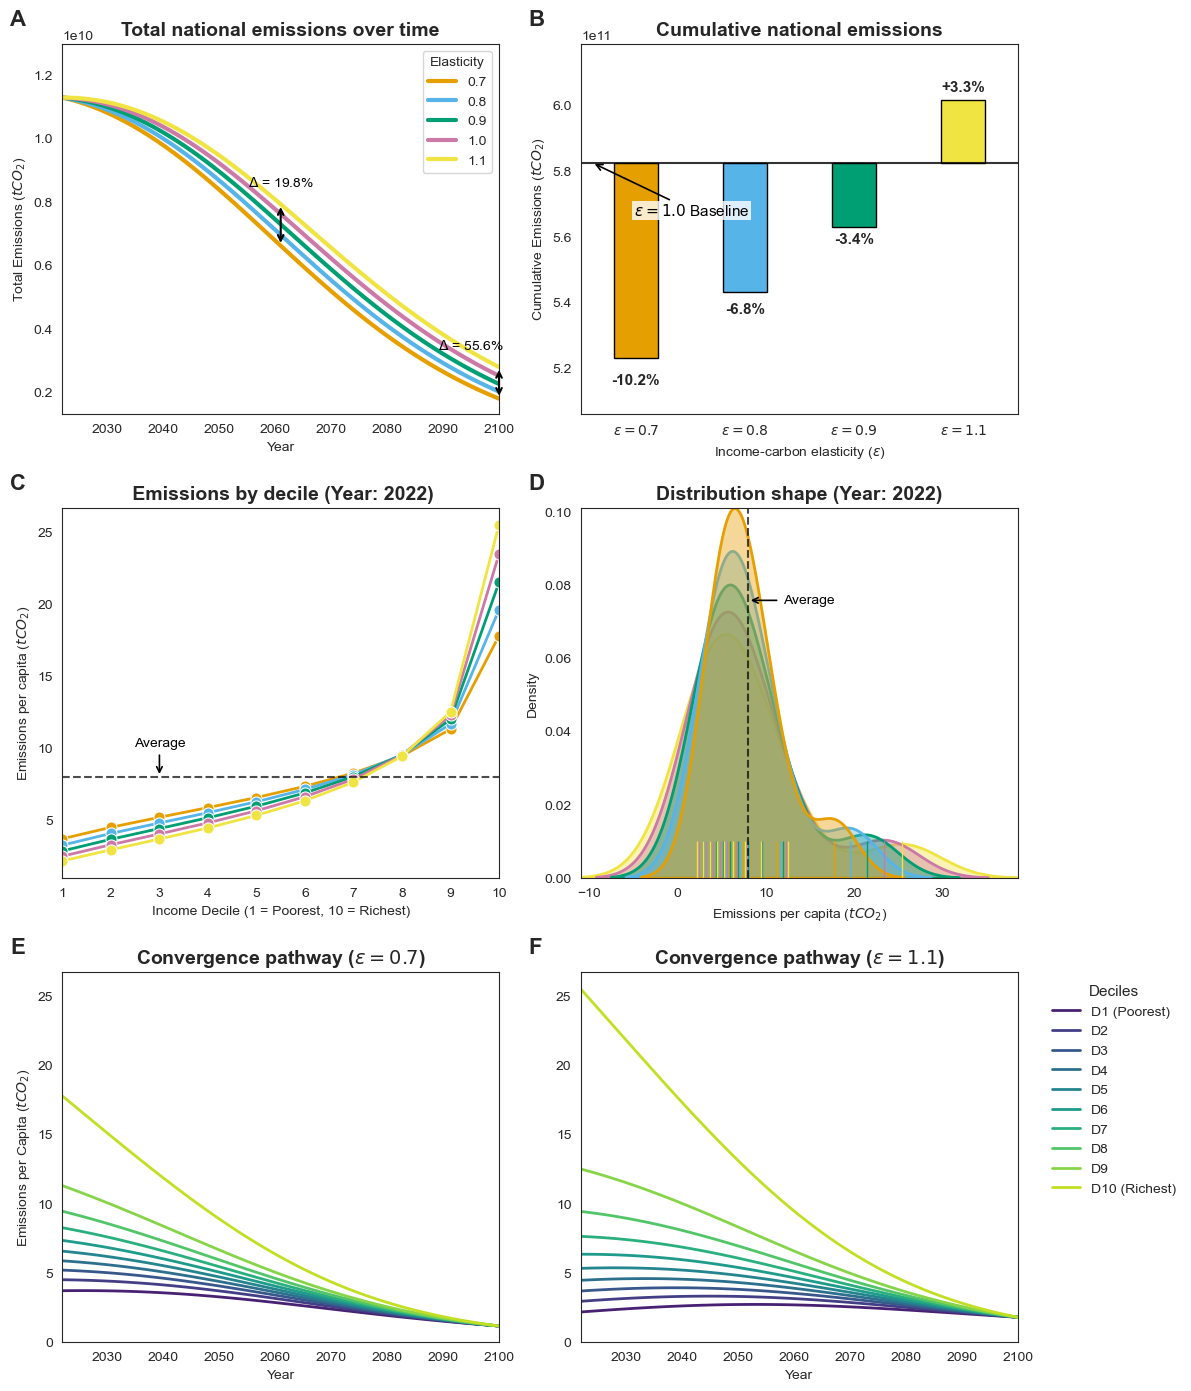

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data & Set Target Scenario
# ==========================================
try:
    df = pd.read_parquet("../data/scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("../data/scenario_results_with_deciles.csv")

# Scenario Parameters
target_income = 20000
target_fir = -0.05
target_cdr = "on"  # <--- Ensure this matches what you actually generated!
target_country = "China"
degrowth_assumptions = ["pessimistic_degrowth"]  # List of degrowth assumptions to consider

# Isolate the specific scenario
df_scenario = df[
    (df["Income_Goal"] == target_income) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr) &
    (df["Degrowth_Assumption"].isin(degrowth_assumptions))
].copy()

# Ensure we have a clean string for deciles to sort legends easily
df_scenario["Decile_Label"] = df_scenario["Decile"].apply(
    lambda d: f"D{d} (Poorest)" if d == 1 else (f"D{d} (Richest)" if d == 10 else f"D{d}")
)


# ==============================================================================
# FIGURE 1: The New 6-Panel Mosaic Plot
# ==============================================================================
# Enforce a clean white background
sns.set_style("white")

df_country = df_scenario[df_scenario["Country"] == target_country].copy()
df_macro_country = df_country[['Year', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# Dynamically find the first year so it doesn't crash if the DataFrame is empty
snapshot_year = df_country["Year"].min() if not df_country.empty else 2023 

# Define the new mosaic layout (3 rows, 2 columns): 
layout = """
AB
CD
EF
"""
# Adjusted figsize to accommodate the new 6-panel grid gracefully
fig, axes = plt.subplot_mosaic(layout, figsize=(12, 14))
fig.patch.set_facecolor('white')

# Colorblind-friendly Okabe-Ito palette
cb_colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#F0E442", "#0072B2", "#D55E00", "#000000"]

# Ensure color consistency by manually mapping sorted elasticities
unique_elasticities = sorted(df_macro_country['Elasticity'].unique())
color_dict = {e: cb_colors[i % len(cb_colors)] for i, e in enumerate(unique_elasticities)}

# --- PANEL A: Macro Total Emissions Trajectories ---
sns.lineplot(
    data=df_macro_country, x="Year", y="Macro_Total_Emissions", 
    hue="Elasticity", palette=list(color_dict.values()), linewidth=3, ax=axes['A']
)
axes['A'].set_title("Total national emissions over time", fontsize=14, fontweight='bold')
axes['A'].set_ylabel("Total Emissions ($tCO_2$)")
axes['A'].grid(False) # Gridlines removed
axes['A'].margins(x=0) # 0 margins
axes['A'].text(-0.12, 1.05, "A", transform=axes['A'].transAxes, fontsize=16, fontweight='bold')

# Add per year diff annotation as PERCENTAGE (midway and last year to illustrate magnitude)
years = sorted(df_macro_country['Year'].unique())
if len(years) > 1:
    last_year = years[-1]
    mid_year = years[len(years) // 2]
    
    overall_max = df_macro_country['Macro_Total_Emissions'].max()
    y_padding = overall_max * 0.04 
    
    # === ANNOTATION 1: Mid Year ===
    y1_data = df_macro_country[df_macro_country['Year'] == mid_year]
    y1_max = y1_data['Macro_Total_Emissions'].max()
    y1_min = y1_data['Macro_Total_Emissions'].min()
    
    pct1_diff = ((y1_max - y1_min) / y1_min) * 100
    pct1_str = f"{pct1_diff:.1f}"
        
    axes['A'].annotate('', xy=(mid_year, y1_max), xytext=(mid_year, y1_min),
                       arrowprops=dict(arrowstyle='<->', lw=1.5, color='black'))
    
    axes['A'].text(mid_year, y1_max + y_padding, f"$\Delta$ = {pct1_str}%", 
                   va='bottom', ha='center', fontsize=10, color='black')


    # === ANNOTATION 2: Last Year ===
    y2_data = df_macro_country[df_macro_country['Year'] == last_year]
    y2_max = y2_data['Macro_Total_Emissions'].max()
    y2_min = y2_data['Macro_Total_Emissions'].min()
    
    pct2_diff = ((y2_max - y2_min) / y2_min) * 100
    pct2_str = f"{pct2_diff:.1f}"
        
    axes['A'].annotate('', xy=(last_year, y2_max), xytext=(last_year, y2_min),
                       arrowprops=dict(arrowstyle='<->', lw=1.5, color='black'))
    
    axes['A'].text(last_year - 5, y2_max + y_padding, f"$\Delta$ = {pct2_str}%", 
                   va='bottom', ha='center', fontsize=10, color='black')

    axes['A'].set_ylim(top=overall_max * 1.15)


# --- PANEL B: Cumulative Emissions Waterfall Chart ---
cum_emissions = df_macro_country.groupby('Elasticity')['Macro_Total_Emissions'].sum().reset_index()

base_row = cum_emissions[cum_emissions['Elasticity'] == 1.0]
if not base_row.empty:
    base_val = base_row['Macro_Total_Emissions'].values[0]
    df_plot = cum_emissions[cum_emissions['Elasticity'] != 1.0].copy()
else:
    base_val = cum_emissions['Macro_Total_Emissions'].median() if not cum_emissions.empty else 0
    df_plot = cum_emissions[cum_emissions['Macro_Total_Emissions'] != base_val].copy()

axes['B'].set_title("Cumulative national emissions", fontsize=14, fontweight='bold')
axes['B'].set_ylabel("Cumulative Emissions ($tCO_2$)")
axes['B'].set_xlabel("Income-carbon elasticity ($\epsilon$)")
axes['B'].grid(False) 
axes['B'].text(-0.12, 1.05, "B", transform=axes['B'].transAxes, fontsize=16, fontweight='bold')

# Draw the baseline for Elasticity 1.0
if base_val > 0:
    axes['B'].axhline(base_val, color='black', linewidth=1.5, linestyle='-', alpha=0.8)

    axes['B'].annotate('$\epsilon = 1.0$ Baseline', xy=(-0.4, base_val), 
                       xytext=(30, -40), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                       va='bottom', ha='left', fontsize=11, color='black',
                       bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

# Plot the floating bars (waterfall style)
x_positions = np.arange(len(df_plot))
for idx, (index, row) in enumerate(df_plot.iterrows()):
    e = row['Elasticity']
    val = row['Macro_Total_Emissions']
    delta = val - base_val
    
    axes['B'].bar(
        x=idx, 
        height=delta, 
        bottom=base_val, 
        color=color_dict.get(e, 'grey'), 
        edgecolor='black', 
        width=0.4
    )
    
    if base_val > 0:
        pct = (delta / base_val) * 100
        sign = "+" if pct > 0 else ""
        pct_str = f"{sign}{pct:.1f}%"
            
        va = 'bottom' if delta > 0 else 'top'
        offset = abs(delta) * 0.08 if delta != 0 else base_val * 0.01
        y_pos = val + offset if delta > 0 else val - offset
        
        axes['B'].text(
            x=idx, 
            y=y_pos, 
            s=pct_str, 
            ha='center', 
            va=va, 
            fontsize=11, 
            fontweight='bold'
        )

axes['B'].set_xticks(x_positions)
axes['B'].set_xticklabels([f"$\epsilon = {e}$" for e in df_plot['Elasticity']])
axes['B'].set_xlim(-0.5, len(df_plot) - 0.5)

y_min, y_max = axes['B'].get_ylim()
range_y = y_max - y_min
if range_y == 0:
    range_y = base_val * 0.1
axes['B'].set_ylim(y_min - range_y * 0.15, y_max + range_y * 0.15)


# --- PANEL C: Initial Decile Line Plot ---
df_snapshot = df_country[df_country["Year"] == snapshot_year]

# Safe iloc extraction checking if empty to prevent IndexError
snapshot_means = df_snapshot.groupby('Elasticity')['Decile_Emissions_pc'].mean()
if not snapshot_means.empty:
    assert np.allclose(snapshot_means, snapshot_means.iloc[0]), "Average emissions are not constant across elasticities!"
    avg_emission = snapshot_means.iloc[0]
else:
    avg_emission = 0

sns.lineplot(
    data=df_snapshot, x="Decile", y="Decile_Emissions_pc", hue="Elasticity", 
    palette=list(color_dict.values()), marker="o", markersize=8, linewidth=2, ax=axes['C'], legend=False
)
axes['C'].set_title(f" Emissions by decile (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['C'].set_xlabel("Income Decile (1 = Poorest, 10 = Richest)")
axes['C'].set_ylabel("Emissions per capita ($tCO_2$)")
axes['C'].set_xticks(range(1, 11))
axes['C'].grid(False) 
axes['C'].margins(x=0) 
axes['C'].text(-0.12, 1.05, "C", transform=axes['C'].transAxes, fontsize=16, fontweight='bold')

if avg_emission > 0:
    axes['C'].axhline(avg_emission, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    axes['C'].annotate('Average', xy=(3, avg_emission), xytext=(0, 20), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                       va='bottom', ha='center', fontsize=10, color='black')


# --- PANEL D: KDE Distribution Comparison ---
sns.kdeplot(
    data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
    palette=list(color_dict.values()), fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes['D'], legend=False
)
if not df_snapshot.empty:
    sns.rugplot(
        data=df_snapshot, x="Decile_Emissions_pc", hue="Elasticity", 
        palette=list(color_dict.values()), height=0.1, ax=axes['D'], legend=False
    )
axes['D'].set_title(f"Distribution shape (Year: {snapshot_year})", fontsize=14, fontweight='bold')
axes['D'].set_xlabel("Emissions per capita ($tCO_2$)")
axes['D'].set_ylabel("Density")
axes['D'].grid(False) 
axes['D'].margins(x=0, y=0) 
axes['D'].text(-0.12, 1.05, "D", transform=axes['D'].transAxes, fontsize=16, fontweight='bold')

if avg_emission > 0:
    axes['D'].axvline(avg_emission, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    axes['D'].annotate('Average', xy=(avg_emission, 0.75), xycoords=('data', 'axes fraction'),
                       xytext=(25, 0), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
                       va='center', ha='left', fontsize=10, color='black')


# --- PANEL E: Decile Emissions Over Time (Elasticity = 0.7) ---
df_elast_low = df_country[df_country["Elasticity"] == 0.7].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_low, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['E'], legend=False
)
axes['E'].set_title("Convergence pathway ($\epsilon = 0.7$)", fontsize=14, fontweight='bold')
axes['E'].set_xlabel("Year")
axes['E'].set_ylabel("Emissions per Capita ($tCO_2$)")
axes['E'].grid(False) 
axes['E'].margins(x=0) 
axes['E'].text(-0.12, 1.05, "E", transform=axes['E'].transAxes, fontsize=16, fontweight='bold')


# --- PANEL F: Decile Emissions Over Time (Elasticity = 1.1) ---
df_elast_high = df_country[df_country["Elasticity"] == 1.1].sort_values(by=["Year", "Decile"])
sns.lineplot(
    data=df_elast_high, x="Year", y="Decile_Emissions_pc", hue="Decile_Label", 
    palette="viridis", linewidth=2, ax=axes['F']
)
axes['F'].set_title("Convergence pathway ($\epsilon = 1.1$)", fontsize=14, fontweight='bold')
axes['F'].set_xlabel("Year")
axes['F'].set_ylabel("") # Shared visually with E
axes['F'].grid(False) 
axes['F'].margins(x=0) 
axes['F'].text(-0.12, 1.05, "F", transform=axes['F'].transAxes, fontsize=16, fontweight='bold')


# --- Synchronize Y-Axis for Panels E and F ---
# Safely calculate the max y-limit to avoid errors on empty data
max_y_pathway = 0
if not df_elast_low.empty and not df_elast_high.empty:
    max_y_pathway = max(df_elast_low["Decile_Emissions_pc"].max(), df_elast_high["Decile_Emissions_pc"].max())
    axes['E'].set_ylim(0, max_y_pathway * 1.05)
    axes['F'].set_ylim(0, max_y_pathway * 1.05)

# Clean up legend for Panel F
axes['F'].legend(title="Deciles", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=10, title_fontsize=11)

# Add explicit padding to prevent any overlapping
plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=3.0)
plt.subplots_adjust(top=0.94)

# --- DIRECTORY LOGIC (Navigate up one level) ---
import os

# --- DIRECTORY LOGIC ---
# Determine if we are currently inside 'jupyter_scripts'
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    # We are in jupyter_scripts, step up one level to the root
    output_dir = os.path.join('..', 'figures_supplementary')
else:
    # We are already in the root directory (Convergence)
    output_dir = 'figures_supplementary'

os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'supp_fig8.png')

plt.tight_layout() # Optional, but good practice to ensure nothing is cut off
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

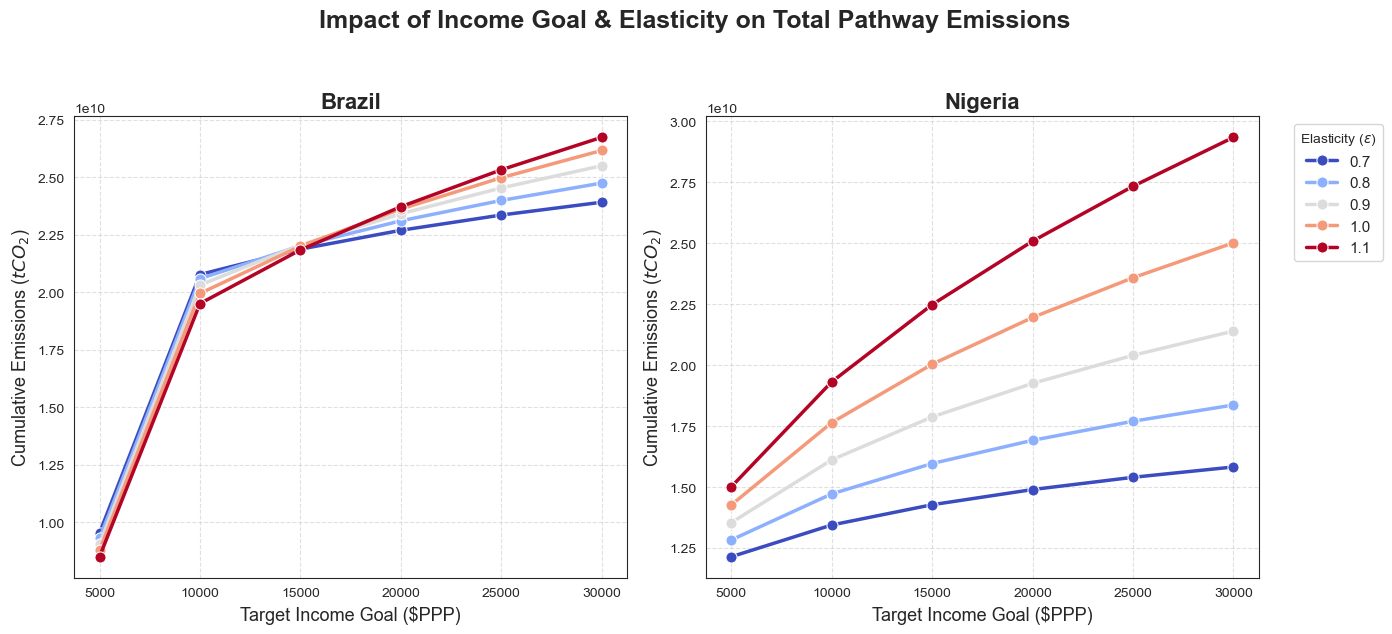

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Data 
# ==========================================
# Updated paths to point to the ../data/ directory
try:
    df = pd.read_parquet("../data/scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("../data/scenario_results_with_deciles.csv")

# ==========================================
# 2. Filter & Prepare the Data
# ==========================================
target_fir = -0.05
target_cdr = "on"  # Changed from "off" to match the generated data
target_degrowth = "optimistic_degrowth" # Added to prevent summing distinct degrowth scenarios
target_countries = ["Brazil", "Nigeria"]

# 1. Isolate the macro data to avoid the 10x decile duplication
df_macro = df[
    (df["Country"].isin(target_countries)) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr) &
    (df["Degrowth_Assumption"] == target_degrowth)
][['Country', 'Year', 'Income_Goal', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# 2. Calculate Cumulative Pathway Emissions (Sum over 2022-2100)
df_cumulative = df_macro.groupby(
    ['Country', 'Income_Goal', 'Elasticity']
)['Macro_Total_Emissions'].sum().reset_index()

# ==========================================
# 3. Create the Side-by-Side Plot
# ==========================================
# sharey=False is important because US absolute emissions are vastly higher than Nigeria's
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for idx, country in enumerate(target_countries):
    ax = axes[idx]
    country_data = df_cumulative[df_cumulative["Country"] == country]
    
    # Safe check to prevent plotting errors if data is missing
    if not country_data.empty:
        sns.lineplot(
            data=country_data, 
            x="Income_Goal", 
            y="Macro_Total_Emissions", 
            hue="Elasticity", 
            palette="coolwarm", 
            marker="o", # Adds dots at each 5000-step income goal
            markersize=8,
            linewidth=2.5, 
            ax=ax
        )
    
    ax.set_title(f"{country}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Target Income Goal ($PPP)", fontsize=13)
    ax.set_ylabel("Cumulative Emissions ($tCO_2$)", fontsize=13)
    ax.grid(True, linestyle="--", alpha=0.6)
    
    # Format the legend beautifully
    if idx == 1 and not country_data.empty:
        ax.legend(title="Elasticity ($\epsilon$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove() # Only need one legend for the whole figure

plt.suptitle("Impact of Income Goal & Elasticity on Total Pathway Emissions", fontsize=18, fontweight='bold', y=1.05)


plt.tight_layout()
plt.show()

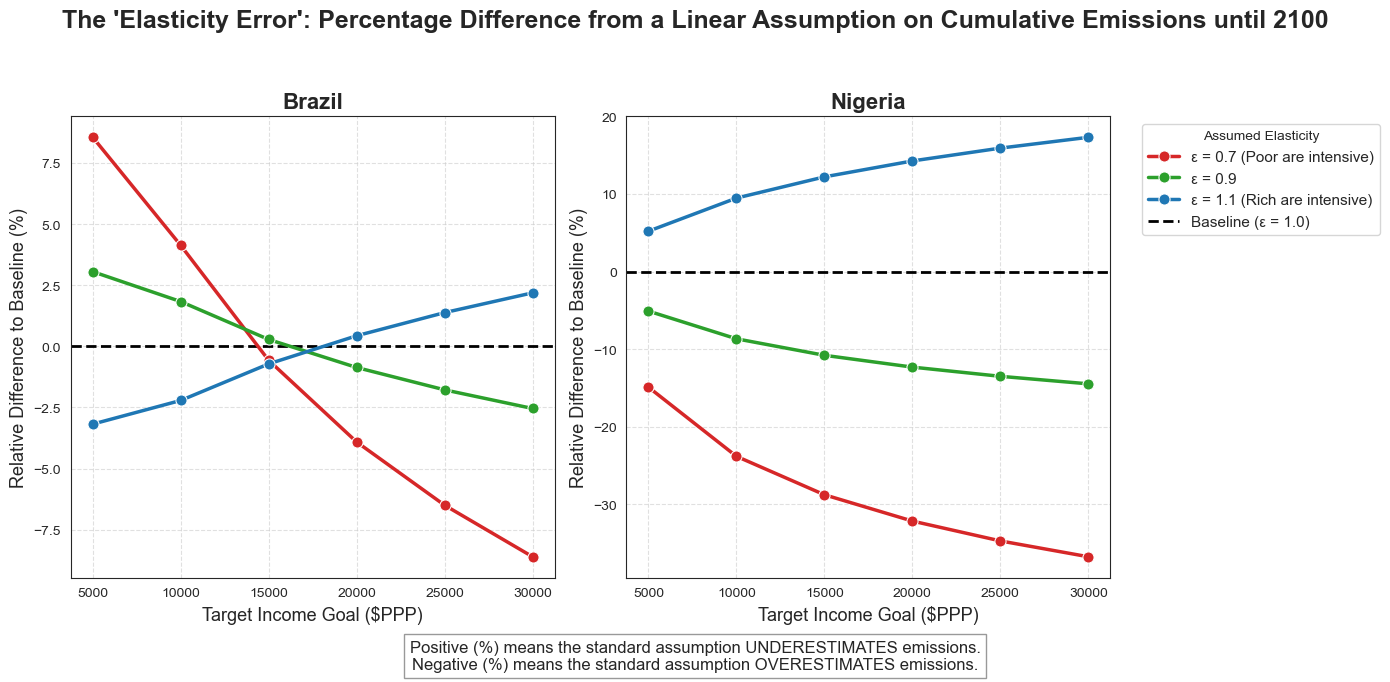

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. Load Data 
# ==========================================
# Updated paths to point to the ../data/ directory
try:
    df = pd.read_parquet("../data/scenario_results_with_deciles.parquet")
except FileNotFoundError:
    df = pd.read_csv("../data/scenario_results_with_deciles.csv")

# ==========================================
# 2. Filter & Prepare the Data
# ==========================================
target_fir = -0.05
target_cdr = "on"  
target_degrowth = "optimistic_degrowth" 
target_countries = ["Brazil", "Nigeria"] # Updated target countries

# 1. Isolate the macro data
df_macro = df[
    (df["Country"].isin(target_countries)) & 
    (df["Final_Improvement_Rate"] == target_fir) & 
    (df["CDR_Assumption"] == target_cdr) &
    (df["Degrowth_Assumption"] == target_degrowth)
][['Country', 'Year', 'Income_Goal', 'Elasticity', 'Macro_Total_Emissions']].drop_duplicates()

# 2. Calculate Cumulative Pathway Emissions
df_cumulative = df_macro.groupby(
    ['Country', 'Income_Goal', 'Elasticity']
)['Macro_Total_Emissions'].sum().reset_index()

# 3. Pivot the data so Elasticities become columns (easier to do math across rows)
df_pivot = df_cumulative.pivot(
    index=['Country', 'Income_Goal'], 
    columns='Elasticity', 
    values='Macro_Total_Emissions'
).reset_index()

# 4. Calculate Relative Differences (%) compared to the baseline (1.0)
# Safe check to ensure columns exist before doing math (Updated for 0.7, 0.9 and 1.1)
if not df_pivot.empty and 1.0 in df_pivot.columns and 0.7 in df_pivot.columns and 0.9 in df_pivot.columns and 1.1 in df_pivot.columns:
    df_pivot['Rel_Diff_0.7'] = ((df_pivot[0.7] - df_pivot[1.0]) / df_pivot[1.0]) * 100
    df_pivot['Rel_Diff_0.9'] = ((df_pivot[0.9] - df_pivot[1.0]) / df_pivot[1.0]) * 100
    df_pivot['Rel_Diff_1.1'] = ((df_pivot[1.1] - df_pivot[1.0]) / df_pivot[1.0]) * 100

    # 5. Melt back to long format for Seaborn plotting
    df_melted = df_pivot.melt(
        id_vars=['Country', 'Income_Goal'], 
        value_vars=['Rel_Diff_0.7', 'Rel_Diff_0.9', 'Rel_Diff_1.1'],
        var_name='Elasticity_Scenario', 
        value_name='Relative_Difference_Pct'
    )

    # Rename the variables so the legend looks clean
    df_melted['Elasticity_Scenario'] = df_melted['Elasticity_Scenario'].replace({
        'Rel_Diff_0.7': 'ε = 0.7 (Poor are intensive)',
        'Rel_Diff_0.9': 'ε = 0.9',
        'Rel_Diff_1.1': 'ε = 1.1 (Rich are intensive)'
    })
else:
    # Create empty df_melted to prevent plotting crash if data is missing
    df_melted = pd.DataFrame(columns=['Country', 'Income_Goal', 'Elasticity_Scenario', 'Relative_Difference_Pct'])

# ==========================================
# 3. Create the Side-by-Side Plot
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False) # Keep sharey=False to see the curve shapes perfectly

for idx, country in enumerate(target_countries):
    ax = axes[idx]
    country_data = df_melted[df_melted["Country"] == country]
    
    if not country_data.empty:
        sns.lineplot(
            data=country_data, 
            x="Income_Goal", 
            y="Relative_Difference_Pct", 
            hue="Elasticity_Scenario", 
            # Added a green hex code (#2ca02c) for 0.9
            palette={
                "ε = 0.7 (Poor are intensive)": "#d62728", 
                "ε = 0.9": "#2ca02c", 
                "ε = 1.1 (Rich are intensive)": "#1f77b4"
            }, 
            marker="o", 
            markersize=8,
            linewidth=2.5, 
            ax=ax
        )
    
    # Add a bold dashed baseline at 0%
    ax.axhline(0, color='black', linestyle='--', linewidth=2, label="Baseline (ε = 1.0)", zorder=1)
    
    ax.set_title(f"{country}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Target Income Goal ($PPP)", fontsize=13)
    ax.set_ylabel("Relative Difference to Baseline (%)", fontsize=13)
    ax.grid(True, linestyle="--", alpha=0.6)
    
    # Format the legend beautifully
    if idx == 1 and not country_data.empty:
        ax.legend(title="Assumed Elasticity", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

plt.suptitle("The 'Elasticity Error': Percentage Difference from a Linear Assumption on Cumulative Emissions until 2100", fontsize=18, fontweight='bold', y=1.05)

plt.figtext(0.5, -0.05, 
            "Positive (%) means the standard assumption UNDERESTIMATES emissions.\n"
            "Negative (%) means the standard assumption OVERESTIMATES emissions.", 
            ha="center", fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()

# --- DIRECTORY LOGIC ---
# Determine if we are currently inside 'jupyter_scripts'
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    # We are in jupyter_scripts, step up one level to the root
    output_dir = os.path.join('..', 'figures_supplementary')
else:
    # We are already in the root directory (Convergence)
    output_dir = 'figures_supplementary'

os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'supp_fig9.png')

plt.tight_layout() # Optional, but good practice to ensure nothing is cut off
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()